In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,roc_curve,RocCurveDisplay,)
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange
from sklearn.preprocessing import StandardScaler


In [ ]:
exprs = pd.read_csv("GSE2034_series_matrix.txt", sep='\t', comment='!')


In [ ]:
exprs.head()

,ID_REF,GSM36777,GSM36778,GSM36779,GSM36780,GSM36781,GSM36782,GSM36783,GSM36784,GSM36785,...,GSM37053,GSM37054,GSM37055,GSM37056,GSM37057,GSM37058,GSM37059,GSM37060,GSM37061,GSM37062
0,1007_s_at,3848.1,6520.9,5285.7,4043.7,4263.6,2949.8,5498.9,3863.1,3370.4,...,4058.2,4017.6,2841.0,2914.2,3681.0,3066.9,2773.0,2984.3,3540.0,2620.0
1,1053_at,228.9,112.5,178.4,398.7,417.7,221.2,280.4,198.2,304.7,...,183.4,356.1,234.6,169.4,94.5,265.5,209.8,160.0,285.7,180.5
2,117_at,213.1,189.8,269.7,312.4,327.1,225.0,243.5,244.4,348.5,...,326.6,234.9,369.6,149.5,236.4,347.9,226.7,252.9,135.1,191.8
3,121_at,1009.4,2083.3,1203.4,1104.4,1043.3,1117.6,1085.4,1423.1,1196.4,...,1041.3,1195.6,751.5,1117.8,1022.4,1127.4,1071.8,1178.5,1256.7,1284.6
4,1255_g_at,31.8,145.8,42.5,108.2,69.2,47.4,84.3,102.0,22.8,...,143.5,32.7,62.6,43.0,100.5,47.0,45.1,146.3,75.9,87.4


In [ ]:
labels = pd.read_csv("clinical__data.csv")

In [ ]:
labels.head()

,GEO asscession number,Column1
0,GSM36793,0.0
1,GSM36796,0.0
2,GSM36797,1.0
3,GSM36798,0.0
4,GSM36800,1.0


In [ ]:
labels = labels.rename(columns={
    "GEO asscession number": "Sample",
    "Column1": "label"
})

labels.head()

,Sample,label
0,GSM36793,0.0
1,GSM36796,0.0
2,GSM36797,1.0
3,GSM36798,0.0
4,GSM36800,1.0


In [ ]:
expr = exprs.set_index("ID_REF")

X = expr.T.reset_index()
X = X.rename(columns={"index": "Sample"})

data = X.merge(labels, on="Sample")

data.head()

,Sample,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,label
0,GSM36777,3848.1,228.9,213.1,1009.4,31.8,551.5,176.7,11.9,309.3,...,661.5,33168.9,25644.4,11.1,9.2,25.0,4.2,7.0,10.0,0.0
1,GSM36778,6520.9,112.5,189.8,2083.3,145.8,802.8,278.4,28.3,449.0,...,716.1,54401.4,40720.0,17.1,62.0,21.4,9.3,11.2,15.7,1.0
2,GSM36779,5285.7,178.4,269.7,1203.4,42.5,557.5,183.3,56.4,101.9,...,1189.3,61244.1,50878.7,6.4,8.4,7.4,7.1,64.0,4.1,0.0
3,GSM36780,4043.7,398.7,312.4,1104.4,108.2,568.5,187.7,42.1,899.1,...,801.1,62292.1,46870.8,13.5,10.8,16.0,4.6,12.2,7.3,0.0
4,GSM36781,4263.6,417.7,327.1,1043.3,69.2,653.2,185.8,21.8,3629.3,...,191.1,57295.1,40847.1,19.8,30.5,22.1,7.3,5.5,11.6,0.0


In [ ]:
y = data["label"].astype(int)

X = data.drop(columns=["Sample", "label"])
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean())

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=y
)
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False,
)

In [ ]:
class GeneCNN(nn.Module):
    def __init__(self, num_genes):
        super(GeneCNN, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)

        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.flatten_size = 64 * (num_genes // 2)

        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
import torch.optim as optim

num_genes = X_train.shape[1]

cnn = GeneCNN(num_genes)

cnn.train()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.0001, weight_decay=0.0001)

# Train the model
losses = []
for epoch in range(25):
    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)
        X = X.unsqueeze(1)

        optimizer.zero_grad()
        yhat = cnn(X)
        loss = loss_fn(
            yhat,
            y
        )
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.9061768054962158
Epoch 5, Loss: 0.3408973217010498
Epoch 10, Loss: 0.09300747513771057
Epoch 15, Loss: 0.006175994873046875
Epoch 20, Loss: 0.013971183449029922


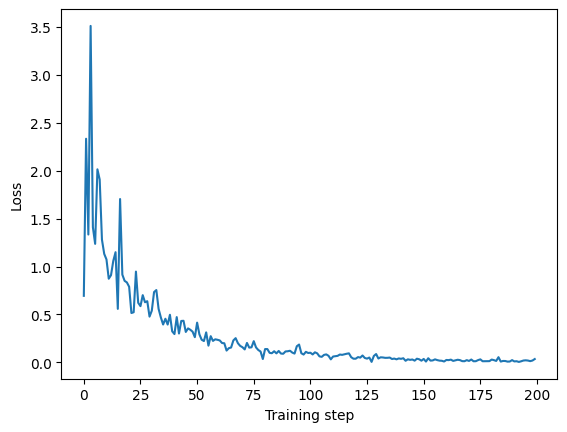

In [ ]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
plt.show()

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

cnn.eval()

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        X_batch = X_batch.unsqueeze(1)

        logits = cnn(X_batch)
        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).int()
        all_probs.extend(probs.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())
        all_true.extend(y_batch.numpy().flatten())

accuracy = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, zero_division=0)
recall = recall_score(all_true, all_preds, zero_division=0)
f1 = f1_score(all_true, all_preds, zero_division=0)
auc = roc_auc_score(all_true, all_probs)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", auc)

Accuracy: 0.7931034482758621
Precision: 0.7692307692307693
Recall: 0.5263157894736842
F1-score: 0.625
ROC-AUC: 0.8785425101214573


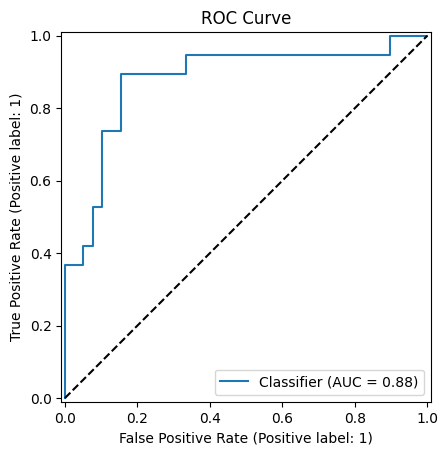

In [ ]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(all_true, all_probs, ax=ax)
ax.plot([0, 1], [0, 1], color="black", linestyle="dashed")
plt.title("ROC Curve")
plt.show()